# Dynamic Model of a Continuum Robot with Triangular Prisms
### Euler–Lagrange Formulation

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# coordenadas
theta, phi = sp.symbols('theta phi')

# velocidades
theta_dot, phi_dot = sp.symbols('theta_dot phi_dot')

# aceleraciones
theta_ddot, phi_ddot = sp.symbols('theta_ddot phi_ddot')

# propiedades fisicas
m_backbone, m_prism = sp.symbols('m_backbone m_prism',positive=True)

# geometria
L, a, r_hole, h = sp.symbols('L a r_hole h',positive=True)

# material
g, E_mod, I_geom = sp.symbols('g E_mod I_geom',positive=True)

# cables
T1, T2, T3 = sp.symbols('T1 T2 T3', positive=True)

# radio de los cables respecto al backbone
R_c = sp.symbols('R_c', positive=True)

# coordenada continua
s = sp.symbols('s')

In [2]:
# vector de coordenadas generalizadas
q = sp.Matrix([theta, phi])

# vector de velocidades y aceleraciones generalizadas
q_dot = sp.Matrix([theta_dot, phi_dot])
q_ddot = sp.Matrix([theta_ddot, phi_ddot])

q_ddot

Matrix([
[theta_ddot],
[  phi_ddot]])

In [3]:
#m = sp.symbols('m')      # backbone mass
#g = sp.symbols('g')      # gravity
#EI = sp.symbols('EI')    # bending stiffness

# linear density
mu = m_backbone/L

In [4]:
# funciones de posición
#x = (1-sp.cos(theta*s/L))/theta * sp.cos(phi)
#y = (1-sp.cos(theta*s/L))/theta * sp.sin(phi)
#z = sp.sin(theta*s/L)/theta

x = L/theta * (1-sp.cos(theta*s/L)) * sp.cos(phi)
y = L/theta * (1-sp.cos(theta*s/L)) * sp.sin(phi)
z = L/theta * sp.sin(theta*s/L)

# vector de posición
r_backbone = sp.Matrix([x,y,z])
r_backbone

Matrix([
[L*(1 - cos(s*theta/L))*cos(phi)/theta],
[L*(1 - cos(s*theta/L))*sin(phi)/theta],
[               L*sin(s*theta/L)/theta]])

#Energía cinética de backbone

In [5]:
# Jacobiano del backbone
Jv = r_backbone.jacobian(q)

# velocidad del backbone
r_dot = Jv * q_dot

Jv

Matrix([
[-L*(1 - cos(s*theta/L))*cos(phi)/theta**2 + s*sin(s*theta/L)*cos(phi)/theta, -L*(1 - cos(s*theta/L))*sin(phi)/theta],
[-L*(1 - cos(s*theta/L))*sin(phi)/theta**2 + s*sin(phi)*sin(s*theta/L)/theta,  L*(1 - cos(s*theta/L))*cos(phi)/theta],
[                        -L*sin(s*theta/L)/theta**2 + s*cos(s*theta/L)/theta,                                      0]])

In [6]:
# matriz de inercia del backbone
M_flex = sp.integrate(mu * (Jv.T * Jv), (s,0,L))

# energia cinetica del backbone
T_flex = sp.Rational(1,2) * (q_dot.T * M_flex * q_dot)[0]
T_flex = sp.expand(T_flex)
T_flex = sp.simplify(T_flex)
T_flex

L**2*m_backbone*(6*phi_dot**2*theta**2*(cos(theta) - 4)*sin(theta) + theta**3*(18*phi_dot**2 + 4*theta_dot**2) + 24*theta*theta_dot**2*(cos(theta) + 1) - 48*theta_dot**2*sin(theta))/(24*theta**5)

In [7]:
#matriz de inercia - derivar T_flex respecto a las velocidades(Hessiano)
#M11 = sp.diff(sp.diff(T_flex, theta_dot), theta_dot)
#M22 = sp.diff(sp.diff(T_flex, phi_dot), phi_dot)
#M12 = sp.diff(sp.diff(T_flex, theta_dot), phi_dot)
#M = sp.Matrix([[M11, M12],[M12, M22]])

M_flex = sp.simplify(sp.hessian(T_flex, (theta_dot, phi_dot)))
M_flex

Matrix([
[L**2*m_backbone*(theta**3 + 6*theta*(cos(theta) + 1) - 12*sin(theta))/(3*theta**5),                                                                    0],
[                                                                                 0, L**2*m_backbone*(3*theta + (cos(theta) - 4)*sin(theta))/(2*theta**3)]])

#6. Energía cinética de los prismas triangulares.

In [8]:
#Celda — posiciones de los prismas(5 unidades)
s_prisms = [L*i/6 for i in range(1,6)]
s_prisms

[L/6, L/3, L/2, 2*L/3, 5*L/6]

In [9]:
#Energía cinética traslacional
T_prisms = 0
# masa del prisma
#m_p = sp.symbols('m_p')

for si in s_prisms:

    Jv_i = Jv.subs(s, si)
    v_i = Jv_i * q_dot
    T_prisms += sp.Rational(1,2) * m_prism * (v_i.T * v_i)[0]

T_prisms = sp.expand(T_prisms)
T_prisms = sp.trigsimp(T_prisms)
T_prisms = sp.simplify(T_prisms)
T_prisms

-L**2*m_prism*(-theta**2*(144*phi_dot**2*sin(theta/3)**4 - 72*phi_dot**2*cos(theta/6) - 54*phi_dot**2*cos(theta/3) - 72*phi_dot**2*cos(theta/2) + 18*phi_dot**2*cos(2*theta/3) - 72*phi_dot**2*cos(5*theta/6) + 18*phi_dot**2*cos(theta) + 18*phi_dot**2*cos(5*theta/3) + 216*phi_dot**2 + 55*theta_dot**2) + 12*theta*theta_dot**2*(sin(theta/6) + 2*sin(theta/3) + 3*sin(theta/2) + 4*sin(2*theta/3) + 5*sin(5*theta/6)) + 72*theta_dot**2*(cos(theta/6) + cos(theta/3) + cos(theta/2) + cos(2*theta/3) + cos(5*theta/6) - 5))/(72*theta**4)

In [10]:
# matriz de inercia debida a los prismas
M_prisms = sp.simplify(sp.hessian(T_prisms, (theta_dot, phi_dot)))

M_prisms

Matrix([
[-L**2*m_prism*(-55*theta**2 + 12*theta*(sin(theta/6) + 2*sin(theta/3) + 3*sin(theta/2) + 4*sin(2*theta/3) + 5*sin(5*theta/6)) + 72*cos(theta/6) + 72*cos(theta/3) + 72*cos(theta/2) + 72*cos(2*theta/3) + 72*cos(5*theta/6) - 360)/(36*theta**4),                                                                                                                                                                       0],
[                                                                                                                                                                                                                                               0, L**2*m_prism*(8*sin(theta/3)**4 - 4*cos(theta/6) - 3*cos(theta/3) - 4*cos(theta/2) + cos(2*theta/3) - 4*cos(5*theta/6) + cos(theta) + cos(5*theta/3) + 12)/(2*theta**2)]])

In [11]:
#energía cinética rotacional de los prismas

In [12]:
# parametros geometricos del prisma
#a → lado del triángulo equilátero
#r → radio del hueco circular
#h → espesor del prisma

#a, r, h = sp.symbols('a r h', positive=True)

#area del prisma
A_tri = sp.sqrt(3)/4 * a**2
A_hole = sp.pi * r_hole**2
A_total = A_tri - A_hole

#inercia de area
I_tri = sp.sqrt(3)/96 * a**4
I_circ = sp.pi/4 * r_hole**4
I_area = I_tri - I_circ

#inercia en x e y
Ixx = sp.simplify(m_prism*(I_area/A_total + h**2/12))
Iyy = Ixx

#Inercia respecto al eje z
Izz = sp.simplify(2*m_prism*I_area/A_total)
Izz

m_prism*(sqrt(3)*a**4 - 24*pi*r_hole**4)/(12*(sqrt(3)*a**2 - 4*pi*r_hole**2))

In [13]:
#definir tensor de inercia
I_prism = sp.Matrix([
    [Ixx,0,0],
    [0,Iyy,0],
    [0,0,Izz]
])

#Velocidad angular
#omega = sp.Matrix([
#    theta_dot*sp.cos(phi),
#    theta_dot*sp.sin(phi),
#    phi_dot
#])

omega = sp.Matrix([
    -theta_dot*sp.sin(phi) - phi_dot*sp.sin(theta)*sp.cos(phi),
     theta_dot*sp.cos(phi) - phi_dot*sp.sin(theta)*sp.sin(phi),
     phi_dot*(1 - sp.cos(theta))
])
I_prism

Matrix([
[m_prism*(sqrt(3)*a**4 + 2*h**2*(sqrt(3)*a**2 - 4*pi*r_hole**2) - 24*pi*r_hole**4)/(24*(sqrt(3)*a**2 - 4*pi*r_hole**2)),                                                                                                                      0,                                                                             0],
[                                                                                                                     0, m_prism*(sqrt(3)*a**4 + 2*h**2*(sqrt(3)*a**2 - 4*pi*r_hole**2) - 24*pi*r_hole**4)/(24*(sqrt(3)*a**2 - 4*pi*r_hole**2)),                                                                             0],
[                                                                                                                     0,                                                                                                                      0, m_prism*(sqrt(3)*a**4 - 24*pi*r_hole**4)/(12*(sqrt(3)*a**2 - 4*pi*r_hole**2))]])

In [14]:
#Energía rotacional de los 5 prismas
T_rot_prisms = 0

for si in s_prisms:

    T_rot_prisms += sp.Rational(1,2)*(omega.T * I_prism * omega)[0]

T_rot_prisms = sp.simplify(T_rot_prisms)
M_rot_prisms = sp.simplify(sp.hessian(T_rot_prisms,(theta_dot,phi_dot)))
M_rot_prisms


Matrix([
[5*m_prism*(sqrt(3)*a**4 + 2*h**2*(sqrt(3)*a**2 - 4*pi*r_hole**2) - 24*pi*r_hole**4)/(24*(sqrt(3)*a**2 - 4*pi*r_hole**2)),                                                                                                                                                                                                 0],
[                                                                                                                       0, 5*m_prism*((2*sqrt(3)*a**4 - 48*pi*r_hole**4)*(cos(theta) - 1)**2 + (sqrt(3)*a**4 + 2*h**2*(sqrt(3)*a**2 - 4*pi*r_hole**2) - 24*pi*r_hole**4)*sin(theta)**2)/(24*(sqrt(3)*a**2 - 4*pi*r_hole**2))]])

In [15]:
#Energia cinetica total
M_total = sp.expand(M_flex + M_prisms + M_rot_prisms)
M_total = sp.trigsimp(M_total)
M_total = sp.simplify(M_total)
M_total


Matrix([
[(-288*L**2*m_backbone*(sqrt(3)*a**2 - 4*pi*r_hole**2)*sin(theta) - 24*L**2*m_prism*theta**2*(sqrt(3)*a**2 - 4*pi*r_hole**2)*(sin(theta/6) + 2*sin(theta/3) + 3*sin(theta/2) + 4*sin(2*theta/3) + 5*sin(5*theta/6)) + 2*L**2*theta**3*(12*m_backbone + 55*m_prism)*(sqrt(3)*a**2 - 4*pi*r_hole**2) + 144*L**2*theta*(sqrt(3)*a**2 - 4*pi*r_hole**2)*(m_backbone*cos(theta) + m_backbone - m_prism*cos(theta/6) - m_prism*cos(theta/3) - m_prism*cos(theta/2) - m_prism*cos(2*theta/3) - m_prism*cos(5*theta/6) + 5*m_prism) + 15*m_prism*theta**5*(sqrt(3)*a**4 + 2*sqrt(3)*a**2*h**2 - 8*pi*h**2*r_hole**2 - 24*pi*r_hole**4))/(72*theta**5*(sqrt(3)*a**2 - 4*pi*r_hole**2)),                                                                                                                                                                                                                                                                                                                                                 

#Energía potencial

In [16]:
#Energia gravitacional del backbone

# gravedad y masa del backbone
#g, m = sp.symbols('g m')

V_backbone = sp.integrate(mu * g * z, (s,0,L))

V_backbone = sp.simplify(V_backbone)

V_backbone

Piecewise((L*g*m_backbone*(1 - cos(theta))/theta**2, Ne(theta/L, 0)), (0, True))

In [17]:
V_backbone = g*m_backbone*L*(1-sp.cos(theta))/theta**2
V_backbone

L*g*m_backbone*(1 - cos(theta))/theta**2

In [18]:
#energía potencial gravitacional de los prismas
V_prisms = 0

for si in s_prisms:

    z_i = z.subs(s, si)

    V_prisms += m_prism * g * z_i

V_prisms = sp.simplify(V_prisms)

V_prisms

L*g*m_prism*(sin(theta/6) + sin(theta/3) + sin(theta/2) + sin(2*theta/3) + sin(5*theta/6))/theta

In [19]:
#Energia elastica del backbone

#E, I = sp.symbols('E I')
V_elastic = E_mod*I_geom*theta**2/(2*L)
V_elastic

E_mod*I_geom*theta**2/(2*L)

In [20]:
#Energía potencial total
V_total = sp.simplify(V_backbone + V_prisms + V_elastic)
V_total

(E_mod*I_geom*theta**4/2 - L**2*g*m_backbone*(cos(theta) - 1) + L**2*g*m_prism*theta*(sin(theta/6) + sin(theta/3) + sin(theta/2) + sin(2*theta/3) + sin(5*theta/6)))/(L*theta**2)

In [21]:
#Matriz de Coriolis: Ahora calculamos los símbolos de Christoffel
C = sp.zeros(2,2)

for i in range(2):
    for j in range(2):
        for k in range(2):

            C[i,j] += sp.Rational(1,2)*(
                sp.diff(M_total[i,j], q[k]) +
                sp.diff(M_total[i,k], q[j]) -
                sp.diff(M_total[j,k], q[i])
            )*q_dot[k]

C = sp.expand(C)
C = sp.trigsimp(C)
C = sp.simplify(C)

C


Matrix([
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [22]:
#Vector de gravedad
G = sp.Matrix([sp.diff(V_backbone + V_prisms, qi) for qi in q])
K = sp.Matrix([sp.diff(V_elastic, qi) for qi in q])
G

Matrix([
[L*g*m_backbone*sin(theta)/theta**2 - 2*L*g*m_backbone*(1 - cos(theta))/theta**3 + L*g*m_prism*(cos(theta/6)/6 + cos(theta/3)/3 + cos(theta/2)/2 + 2*cos(2*theta/3)/3 + 5*cos(5*theta/6)/6)/theta - L*g*m_prism*(sin(theta/6) + sin(theta/3) + sin(theta/2) + sin(2*theta/3) + sin(5*theta/6))/theta**2],
[                                                                                                                                                                                                                                                                                                     0]])

In [23]:
print(K.shape)
print(K.free_symbols)

(2, 1)
{I_geom, E_mod, L, theta}


In [24]:
#l modelo dinámico
tau = M_total*q_ddot + C*q_dot + G + K
#tau = sp.expand(tau)
#tau = sp.trigsimp(tau)
tau = sp.simplify(tau)
tau

Matrix([
[(E_mod*I_geom*theta**7*(sqrt(3)*a**2 - 4*pi*r_hole**2) + L**3*theta_dot**2*(sqrt(3)*a**2 - 4*pi*r_hole**2)*(360*m_backbone*sin(theta) + theta**3*(-12*m_backbone + 32*m_prism*sin(theta/3)**2 - m_prism*cos(theta/6) - 4*m_prism*cos(theta/3) - 9*m_prism*cos(theta/2) - 25*m_prism*cos(5*theta/6) - 71*m_prism) + theta**2*(-36*m_backbone*sin(theta) + 24*m_prism*sin(theta/6) + 48*m_prism*sin(theta/3) + 72*m_prism*sin(theta/2) + 96*m_prism*sin(2*theta/3) + 120*m_prism*sin(5*theta/6)) + 72*theta*(-3*m_backbone*cos(theta) - 2*m_backbone + 2*m_prism*cos(theta/6) + 2*m_prism*cos(theta/3) + 2*m_prism*cos(theta/2) + 2*m_prism*cos(2*theta/3) + 2*m_prism*cos(5*theta/6) - 10*m_prism))/36 + 2*L**2*g*m_backbone*theta**3*(sqrt(3)*a**2 - 4*pi*r_hole**2)*(cos(theta) - 1) + L**2*g*m_prism*theta**5*(sqrt(3)*a**2 - 4*pi*r_hole**2)*(cos(theta/6) + 2*cos(theta/3) + 3*cos(theta/2) + 4*cos(2*theta/3) + 5*cos(5*theta/6))/6 + L**2*g*theta**4*(sqrt(3)*a**2 - 4*pi*r_hole**2)*(m_backbone*sin(theta) - m_prism*(s



# Calculo de fuerzas en cables

In [25]:
phi_i_list = [sp.pi/2 - phi, 7*sp.pi/6 - phi, 11*sp.pi/6 - phi]

L_list = []

T_list = [T1, T2, T3]

for phi_i in phi_i_list:
    Li = L - theta * R_c * sp.cos(phi_i)
    L_list.append(sp.simplify(Li))

In [26]:
tau_cables = sp.Matrix([0,0])

for i in range(3):

    Li = L_list[i]
    Ti = T_list[i]
    tau_i = sp.Matrix([ sp.diff(Li, theta), sp.diff(Li, phi)]) * Ti
    tau_cables += tau_i

tau_cables = sp.simplify(
tau_cables
)

tau_cables

Matrix([
[      R_c*(-T1*sin(phi) + T2*sin(phi + pi/3) - T3*cos(phi + pi/6))],
[R_c*theta*(-T1*cos(phi) + T2*cos(phi + pi/3) + T3*sin(phi + pi/6))]])

# FORWARD DYNAMICS
# ==========================================

Entradas:
- Tensiones de cables

Salidas:
- Coordenadas generalizadas
- Movimiento dinámico del robot

In [27]:
# =====================================
# ACELERACIONES GENERALIZADAS
# =====================================
#q_ddot_expr = sp.simplify(M_total.inv() * (tau_cables- C*q_dot- G- K))
rhs = (tau_cables - C*q_dot - G - K)

q_ddot_expr = sp.simplify(M_total.LUsolve(rhs))

sp.simplify(q_ddot_expr)

Matrix([
[(72*E_mod*I_geom*theta**7*(sqrt(3)*a**2 - 4*pi*r_hole**2) + 2*L**3*theta_dot**2*(sqrt(3)*a**2 - 4*pi*r_hole**2)*(360*m_backbone*sin(theta) + theta**3*(-12*m_backbone + 32*m_prism*sin(theta/3)**2 - m_prism*cos(theta/6) - 4*m_prism*cos(theta/3) - 9*m_prism*cos(theta/2) - 25*m_prism*cos(5*theta/6) - 71*m_prism) + theta**2*(-36*m_backbone*sin(theta) + 24*m_prism*sin(theta/6) + 48*m_prism*sin(theta/3) + 72*m_prism*sin(theta/2) + 96*m_prism*sin(2*theta/3) + 120*m_prism*sin(5*theta/6)) + 72*theta*(-3*m_backbone*cos(theta) - 2*m_backbone + 2*m_prism*cos(theta/6) + 2*m_prism*cos(theta/3) + 2*m_prism*cos(theta/2) + 2*m_prism*cos(2*theta/3) + 2*m_prism*cos(5*theta/6) - 10*m_prism)) + 144*L**2*g*m_backbone*theta**3*(sqrt(3)*a**2 - 4*pi*r_hole**2)*(cos(theta) - 1) + 12*L**2*g*m_prism*theta**5*(sqrt(3)*a**2 - 4*pi*r_hole**2)*(cos(theta/6) + 2*cos(theta/3) + 3*cos(theta/2) + 4*cos(2*theta/3) + 5*cos(5*theta/6)) + 72*L**2*g*theta**4*(sqrt(3)*a**2 - 4*pi*r_hole**2)*(m_backbone*sin(theta) - m_

In [28]:
#condiciones iniciales
from scipy.integrate import solve_ivp
import numpy as np
x0 = [
    0.6,   # theta
    0.0,   # phi
    0.0,   # theta_dot
    0.0    # phi_dot
]


In [29]:
#valores a todos los parámetros físicos
params = {
    m_backbone: 0.03,       # masa backbone (kg)
    m_prism: 0.01,    # masa prisma (kg)
    L: 0.105,      # longitud (m)
    a: 0.07,      # lado del triangulo (m)
    r_hole: 0.01,     # radio del hueco (m)
    h: 0.014,      # espesor prisma (m)
    g: 9.81,
    E_mod: 2e6,       # modulo de Young (ejemplo silicona)
    I_geom: 7.854e-09,      # momento de area
    R_c: 0.005        #distancia desde centro al cable
}

In [30]:
# =====================================
# MODELO NUMERICO
# =====================================

q_ddot_num = sp.simplify(q_ddot_expr.subs(params))
q_ddot_num

Matrix([
[(phi_dot**2*theta**2*(0.15*theta**4*(-8.32e-8*pi*cos(theta) + 2.20892e-5*sqrt(3)*cos(theta) - 4.802e-5*sqrt(3) + 4.8e-7*pi)*sin(theta) + theta**2*(-6.4827e-6*sqrt(3)*sin(theta/6) + 5.292e-7*pi*sin(theta/6) - 9.72405e-6*sqrt(3)*sin(theta/3) + 7.938e-7*pi*sin(theta/3) - 1.94481e-5*sqrt(3)*sin(theta/2) + 1.5876e-6*pi*sin(theta/2) - 1.94481e-5*sqrt(3)*sin(2*theta/3) + 1.5876e-6*pi*sin(2*theta/3) - 3.24135e-5*sqrt(3)*sin(5*theta/6) + 2.646e-6*pi*sin(5*theta/6) - 7.938e-7*pi*sin(theta) + 9.72405e-6*sqrt(3)*sin(theta) - 1.0584e-6*pi*sin(4*theta/3) + 1.29654e-5*sqrt(3)*sin(4*theta/3) - 1.323e-6*pi*sin(5*theta/3) + 1.620675e-5*sqrt(3)*sin(5*theta/3)) + 0.19845*theta*(-6.4e-5*pi*sin(theta/3)**4 + 0.000784*sqrt(3)*sin(theta/3)**4 - 0.000392*sqrt(3)*cos(theta/6) + 3.2e-5*pi*cos(theta/6) - 0.000294*sqrt(3)*cos(theta/3) + 2.4e-5*pi*cos(theta/3) - 0.000392*sqrt(3)*cos(theta/2) + 3.2e-5*pi*cos(theta/2) - 8.0e-6*pi*cos(2*theta/3) + 9.8e-5*sqrt(3)*cos(2*theta/3) - 0.000392*sqrt(3)*cos(5*theta/

In [31]:
q_ddot_num = q_ddot_expr.subs(params)
print(q_ddot_num.free_symbols)

{T2, T3, T1, theta_dot, phi, phi_dot, theta}


In [32]:
# =====================================
# FUNCIONES NUMERICAS
# =====================================

qddot_func = sp.lambdify((theta,phi,theta_dot,phi_dot,T1,T2,T3),q_ddot_num,modules='numpy')

In [33]:
#definir sistema dinámico
def dynamics(t, x):

    theta_, phi_, theta_d_, phi_d_ = x

    T1_ = 2.0
    T2_ = 1.0
    T3_ = 0.5

    qdd = qddot_func(
        theta_,phi_,
        theta_d_,phi_d_,
        T1_,T2_,T3_
    )
    print(qdd)

    qdd = np.array(qdd, dtype=float).flatten()

    theta_dd = qdd[0]
    phi_dd   = qdd[1]

    return [
        theta_d_,phi_d_,
        theta_dd,phi_dd
    ]

In [34]:
sol = solve_ivp(
    dynamics,
    [0, 2],
    x0,
    t_eval=np.linspace(0,2,500)
)

[[-1697.83206924]
 [ -212.21253333]]
[[-1697.83206924]
 [ -212.21253333]]
[[-1697.83206924]
 [ -212.21253335]]
[[-1697.83206916]
 [ -212.21253338]]
[[-1697.83206868]
 [ -212.21253365]]
[[-1697.83206854]
 [ -212.21253373]]
[[-1697.83206836]
 [ -212.21253383]]
[[-1697.83206836]
 [ -212.21253383]]
[[-1697.83206472]
 [ -212.21253743]]
[[-1697.83205508]
 [ -212.21254129]]
[[-1697.83199754]
 [ -212.21257362]]
[[-1697.83198268]
 [ -212.21258198]]
[[-1697.83196214]
 [ -212.21259352]]
[[-1697.83196214]
 [ -212.21259352]]
[[-1697.83156283]
 [ -212.21297301]]
[[-1697.83058127]
 [ -212.21336953]]
[[-1697.82473915]
 [ -212.21665264]]
[[-1697.82323719]
 [ -212.2174967 ]]
[[-1697.82116305]
 [ -212.21866233]]
[[-1697.82116306]
 [ -212.21866233]]
[[-1697.78087792]
 [ -212.2568119 ]]
[[-1697.6825463 ]
 [ -212.29657491]]
[[-1697.09749399]
 [ -212.62569772]]
[[-1696.94710616]
 [ -212.7103409 ]]
[[-1696.73950376]
 [ -212.8272687 ]]
[[-1696.73961849]
 [ -212.82726585]]
[[-1692.70913016]
 [ -216.6624554 ]]
[

In [35]:
tau_cables_func = sp.lambdify(
    (theta,phi,T1,T2,T3),
    tau_cables.subs(params),
    modules='numpy'
)

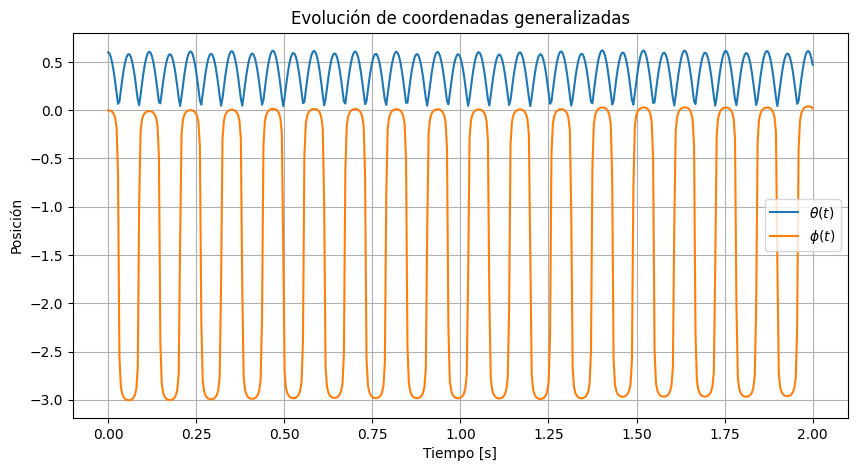

In [36]:
#posiciones
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(sol.t, sol.y[0], label=r'$\theta(t)$')
plt.plot(sol.t, sol.y[1], label=r'$\phi(t)$')

plt.xlabel('Tiempo [s]')
plt.ylabel('Posición')

plt.title('Evolución de coordenadas generalizadas')

plt.grid(True)
plt.legend()

plt.show()

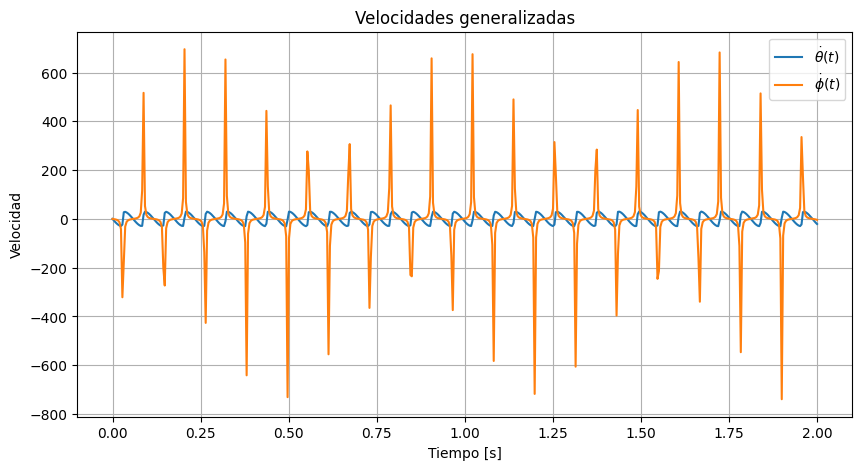

In [37]:
#velociades
plt.figure(figsize=(10,5))

plt.plot(sol.t, sol.y[2], label=r'$\dot{\theta}(t)$')
plt.plot(sol.t, sol.y[3], label=r'$\dot{\phi}(t)$')

plt.xlabel('Tiempo [s]')
plt.ylabel('Velocidad')

plt.title('Velocidades generalizadas')

plt.grid(True)
plt.legend()

plt.show()

In [38]:
equilibrium_eq = sp.simplify(
    tau_cables - G - K
)

equilibrium_eq

Matrix([
[(-E_mod*I_geom*theta**4 - 2*L**2*g*m_backbone*(cos(theta) - 1) - L**2*g*m_prism*theta**2*(cos(theta/6) + 2*cos(theta/3) + 3*cos(theta/2) + 4*cos(2*theta/3) + 5*cos(5*theta/6))/6 + L**2*g*theta*(-m_backbone*sin(theta) + m_prism*(sin(theta/6) + sin(theta/3) + sin(theta/2) + sin(2*theta/3) + sin(5*theta/6))) - L*R_c*theta**3*(T1*sin(phi) - T2*sin(phi + pi/3) + T3*cos(phi + pi/6)))/(L*theta**3)],
[                                                                                                                                                                                                                                                                                                                                       R_c*theta*(-T1*cos(phi) + T2*cos(phi + pi/3) + T3*sin(phi + pi/6))]])

In [39]:
equilibrium_num = sp.simplify(
    equilibrium_eq.subs(params)
)

In [40]:
equilibrium_num = sp.simplify(
    equilibrium_num.subs({
        T1:2.0,
        T2:1.0,
        T3:0.5
    })
)

In [41]:
equilibrium_num

Matrix([
[(-0.1496*theta**4 + theta**3*(-0.00625*sin(phi) + 0.00125*sqrt(3)*cos(phi)) - theta**2*(0.00171675*cos(theta/6) + 0.0034335*cos(theta/3) + 0.00515025*cos(theta/2) + 0.006867*cos(2*theta/3) + 0.00858375*cos(5*theta/6)) + 1.03005*theta*(0.01*sin(theta/6) + 0.01*sin(theta/3) + 0.01*sin(theta/2) + 0.01*sin(2*theta/3) + 0.01*sin(5*theta/6) - 0.03*sin(theta)) - 0.061803*cos(theta) + 0.061803)/theta**3],
[                                                                                                                                                                                                                                                                                                                                                          -0.005*theta*(0.25*sqrt(3)*sin(phi) + 1.25*cos(phi))]])

In [42]:
q_eq = sp.nsolve(
    (
        equilibrium_num[0],
        equilibrium_num[1]
    ),
    (
        theta,
        phi
    ),
    (
        0.5,
        0.0
    )
)

q_eq

Matrix([
[3.22775464135427e-20],
[   0.200183452685489]])

In [43]:
for guess_theta in [0.2,0.5,1.0]:
    
    try:

        sol = sp.nsolve(
            (
                equilibrium_num[0],
                equilibrium_num[1]
            ),
            (
                theta,
                phi
            ),
            (
                guess_theta,
                0.0
            )
        )

        print(sol)

    except:

        pass

Matrix([[0.0461095859546702], [-1.23732315454306]])
Matrix([[3.22775464135427e-20], [0.200183452685489]])
Matrix([[-1.65065776838470e-23], [0.333473496562585]])


# INVERSE DYNAMICS
# ==========================================

Entradas:
- Trayectoria deseada

Salidas:
- Tensiones requeridas
- Longitudes de tendones

In [44]:
# =====================================
# TRAYECTORIA DESEADA
# =====================================

t = np.linspace(0,12,500)

# bending
theta_des = 0.25*np.ones_like(t)

# orientacion
phi_des = np.pi*t/12

In [45]:
# =====================================
# DERIVADAS
# =====================================

theta_dot_des = np.gradient(theta_des,t)
phi_dot_des = np.gradient(phi_des,t)
theta_ddot_des = np.gradient(theta_dot_des,t)
phi_ddot_des = np.gradient(phi_dot_des,t)

In [46]:
# =====================================
# FUNCIONES DINAMICAS
# =====================================

M_func = sp.lambdify((theta,phi),M_total.subs(params),'numpy')
C_func = sp.lambdify((theta,phi,theta_dot,phi_dot),C.subs(params),'numpy')
G_func = sp.lambdify((theta,phi),G.subs(params),'numpy')
K_func = sp.lambdify((theta,phi),K.subs(params),'numpy')

In [47]:
M_func(0.1, 0.2)

array([[4.99269011e-05, 0.00000000e+00],
       [0.00000000e+00, 4.99171732e-07]])

In [48]:
# =====================================
# JACOBIANO TENDON SPACE
# =====================================

L_vec = sp.Matrix(L_list)
J_L = sp.simplify(L_vec.jacobian(q))
J_L_func = sp.lambdify((theta,phi),J_L.subs(params),'numpy')

In [49]:
# =====================================
# DINAMICA INVERSA
# =====================================

from scipy.optimize import lsq_linear

F1 = []
F2 = []
F3 = []

for k in range(len(t)):

    q_ = np.array([theta_des[k],phi_des[k]])
    dq_ = np.array([theta_dot_des[k],phi_dot_des[k]])
    ddq_ = np.array([theta_ddot_des[k],phi_ddot_des[k]])

    # matrices dinamicas
    M_ = np.array(M_func(*q_),dtype=float)
    C_ = np.array(C_func(q_[0],q_[1],dq_[0],dq_[1]),dtype=float)
    G_ = np.array(G_func(*q_),dtype=float).flatten()
    K_ = np.array(K_func(*q_),dtype=float).flatten()

    # generalized forces requeridas
    Q = (M_ @ ddq_+C_ @ dq_+G_+K_)

    # Jacobiano tendon-space
    J_ = np.array(J_L_func(*q_),dtype=float)

    # resolver tensiones
    res = lsq_linear(J_.T,Q,bounds=(0,np.inf))
    T_sol = res.x

    F1.append(T_sol[0])
    F2.append(T_sol[1])
    F3.append(T_sol[2])

In [50]:
# =====================================
# FUNCIONES DE LONGITUDES
# =====================================

L1_func = sp.lambdify((theta,phi),L_list[0].subs(params),'numpy')
L2_func = sp.lambdify((theta,phi),L_list[1].subs(params),'numpy')
L3_func = sp.lambdify((theta,phi),L_list[2].subs(params),'numpy')

In [51]:
# =====================================
# LONGITUDES DE TENDONES
# =====================================

L1_vals = L1_func(theta_des,phi_des)
L2_vals = L2_func(theta_des,phi_des)
L3_vals = L3_func(theta_des,phi_des)

Text(0.5, 1.0, 'Coordenadas generalizadas')

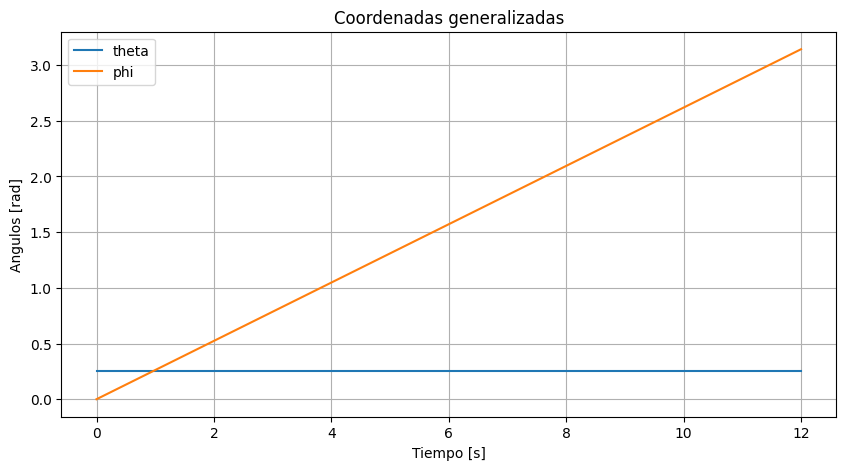

In [52]:
plt.figure(figsize=(10,5))

plt.plot(t, theta_des, label='theta')
plt.plot(t, phi_des, label='phi')

plt.grid(True)
plt.legend()

plt.xlabel('Tiempo [s]')
plt.ylabel('Angulos [rad]')

plt.title('Coordenadas generalizadas')

Text(0.5, 1.0, 'Fuerzas de tendones')

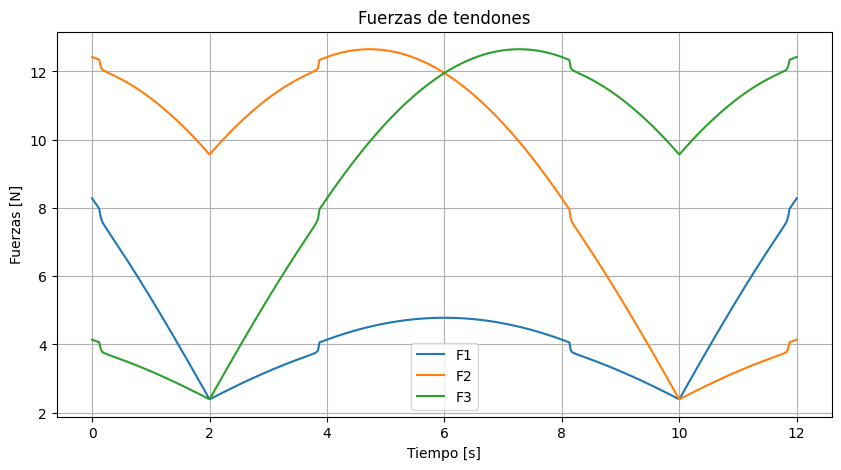

In [53]:
plt.figure(figsize=(10,5))

plt.plot(t, F1, label='F1')
plt.plot(t, F2, label='F2')
plt.plot(t, F3, label='F3')

plt.grid(True)
plt.legend()

plt.xlabel('Tiempo [s]')
plt.ylabel('Fuerzas [N]')

plt.title('Fuerzas de tendones')

Text(0.5, 1.0, 'Longitudes de tendones')

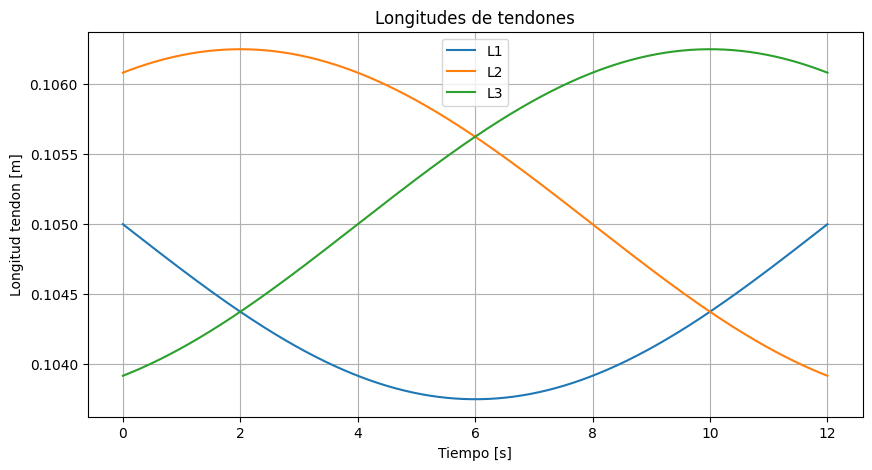

In [54]:
plt.figure(figsize=(10,5))

plt.plot(t, L1_vals, label='L1')
plt.plot(t, L2_vals, label='L2')
plt.plot(t, L3_vals, label='L3')

plt.grid(True)
plt.legend()

plt.xlabel('Tiempo [s]')
plt.ylabel('Longitud tendon [m]')

plt.title('Longitudes de tendones')

# =====================================
# FUNCIONES NUMERICAS DEL MODELO
# =====================================

In [55]:
M_func = sp.lambdify(
    (theta, phi),
    M_total.subs(params),
    modules='numpy'
)

C_func = sp.lambdify(
    (theta, phi, theta_dot, phi_dot),
    C.subs(params),
    modules='numpy'
)

G_func = sp.lambdify(
    (theta, phi),
    G.subs(params),
    modules='numpy'
)

K_func = sp.lambdify(
    (theta, phi),
    K.subs(params),
    modules='numpy'
)

In [56]:
M_num = M_total.subs(params)
M_num

Matrix([
[(0.15*theta**5*(-3.968e-7*pi + 2.59308e-5*sqrt(3)) + 0.0200655*theta**3*(-0.0004*pi + 0.0049*sqrt(3)) - 0.002646*theta**2*(-0.0004*pi + 0.0049*sqrt(3))*(sin(theta/6) + 2*sin(theta/3) + 3*sin(theta/2) + 4*sin(2*theta/3) + 5*sin(5*theta/6)) + 1.5876*theta*(-0.0004*pi + 0.0049*sqrt(3))*(-0.01*cos(theta/6) - 0.01*cos(theta/3) - 0.01*cos(theta/2) - 0.01*cos(2*theta/3) - 0.01*cos(5*theta/6) + 0.03*cos(theta) + 0.08) - 0.095256*(-0.0004*pi + 0.0049*sqrt(3))*sin(theta))/(72*theta**5*(-0.0004*pi + 0.0049*sqrt(3))),                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [57]:
# =====================================
# FORWARD DYNAMICS
# =====================================

qddot_func = sp.lambdify(
    (
        theta,
        phi,
        theta_dot,
        phi_dot,
        T1,
        T2,
        T3
    ),
    q_ddot_num,
    modules='numpy'
)

In [58]:
# =====================================
# JACOBIANO DE TENDONES
# =====================================

L_vec = sp.Matrix(L_list)

J_L = sp.simplify(
    L_vec.jacobian(q)
)

J_L_func = sp.lambdify(
    (theta, phi),
    J_L.subs(params),
    modules='numpy'
)

In [59]:
print(J_L.shape)
print(J_L.free_symbols)

(3, 2)
{phi, R_c, theta}


In [60]:
# =====================================
# LONGITUDES DE CABLE
# =====================================

L1_func = sp.lambdify(
    (theta, phi),
    L_list[0].subs(params),
    modules='numpy'
)

L2_func = sp.lambdify(
    (theta, phi),
    L_list[1].subs(params),
    modules='numpy'
)

L3_func = sp.lambdify(
    (theta, phi),
    L_list[2].subs(params),
    modules='numpy'
)

In [61]:
Q_func = sp.lambdify(
    (
        theta,
        phi,
        theta_dot,
        phi_dot,
        theta_ddot,
        phi_ddot
    ),
    tau.subs(params),
    modules='numpy'
)

In [62]:
Q_func(
    0.1,     # theta
    0.2,     # phi
    0.01,    # theta_dot
    0.02,    # phi_dot
    0.1,     # theta_ddot
    0.1      # phi_ddot
)

array([[1.43501889e-02],
       [5.19129384e-08]])

# ==================================
# FUNCTIONS FOR SOFTPRISM API
# ==================================

In [63]:
M_func_api = sp.lambdify(
    (
        theta,
        L,
        a,
        h,
        m_backbone,
        m_prism,
        r_hole
    ),
    M_total,
    modules='numpy'
)

In [64]:
C_func_api = sp.lambdify(
    (
        theta,
        theta_dot,
        phi_dot,
        L,
        m_backbone,
        m_prism
    ),
    C,
    modules='numpy'
)

In [65]:
G_func_api = sp.lambdify(
    (
        theta,
        L,
        m_backbone,
        m_prism,
        g
    ),
    G,
    modules='numpy'
)

In [66]:
K_func_api = sp.lambdify(
    (
        theta,
        E_mod,
        I_geom,
        L
    ),
    K,
    modules='numpy'
)

In [67]:
J_L_func_api = sp.lambdify(
    (
        theta,
        phi,
        R_c
    ),
    J_L,
    modules='numpy'
)

In [68]:
L1_api = sp.lambdify(
    (
        theta,
        phi,
        L,
        R_c
    ),
    L_list[0],
    modules='numpy'
)

L2_api = sp.lambdify(
    (
        theta,
        phi,
        L,
        R_c
    ),
    L_list[1],
    modules='numpy'
)

L3_api = sp.lambdify(
    (
        theta,
        phi,
        L,
        R_c
    ),
    L_list[2],
    modules='numpy'
)

In [69]:
from sympy.printing.pycode import pycode
M11 = pycode(M_total[0,0])
M22 = pycode(M_total[1,1])
C11 = pycode(C[0,0])
C12 = pycode(C[0,1])
C21 = pycode(C[1,0])
C22 = pycode(C[1,1])
G1 = pycode(G[0])
G2 = pycode(G[1])
K1 = pycode(K[0])
K2 = pycode(K[1])

J11 = pycode(J_L[0,0])
J12 = pycode(J_L[0,1])
J21 = pycode(J_L[1,0])
J22 = pycode(J_L[1,1])
J31 = pycode(J_L[2,0])
J32 = pycode(J_L[2,1])

L1 = pycode(L_list[0])
L2 = pycode(L_list[1])
L3 = pycode(L_list[2])

print(M11)
print(M22)
print(C11)
print(C12)
print(C21)
print(C22)
print(G1)
print(G2)
print(K1)
print(K2)
print(J11)
print(J12)
print(J21)
print(J22)
print(J31)
print(J32)
print(L1)
print(L2)
print(L3)

(1/72)*(-288*L**2*m_backbone*(math.sqrt(3)*a**2 - 4*math.pi*r_hole**2)*math.sin(theta) - 24*L**2*m_prism*theta**2*(math.sqrt(3)*a**2 - 4*math.pi*r_hole**2)*(math.sin((1/6)*theta) + 2*math.sin((1/3)*theta) + 3*math.sin((1/2)*theta) + 4*math.sin((2/3)*theta) + 5*math.sin((5/6)*theta)) + 2*L**2*theta**3*(12*m_backbone + 55*m_prism)*(math.sqrt(3)*a**2 - 4*math.pi*r_hole**2) + 144*L**2*theta*(math.sqrt(3)*a**2 - 4*math.pi*r_hole**2)*(m_backbone*math.cos(theta) + m_backbone - m_prism*math.cos((1/6)*theta) - m_prism*math.cos((1/3)*theta) - m_prism*math.cos((1/2)*theta) - m_prism*math.cos((2/3)*theta) - m_prism*math.cos((5/6)*theta) + 5*m_prism) + 15*m_prism*theta**5*(math.sqrt(3)*a**4 + 2*math.sqrt(3)*a**2*h**2 - 8*math.pi*h**2*r_hole**2 - 24*math.pi*r_hole**4))/(theta**5*(math.sqrt(3)*a**2 - 4*math.pi*r_hole**2))
(1/24)*(12*L**2*m_backbone*(math.sqrt(3)*a**2 - 4*math.pi*r_hole**2)*(math.cos(theta) - 4)*math.sin(theta) + 12*L**2*theta*(math.sqrt(3)*a**2 - 4*math.pi*r_hole**2)*(3*m_backbone + 

In [70]:
with open(
    "../softprism/dynamics/euler_lagrange_model_functions.py",
    "w"
) as f:

    f.write("import numpy as np\n")
    f.write("import math\n\n")

    f.write(
        "def M_func_api("
        "theta,"
        "L,"
        "a,"
        "h,"
        "m_backbone,"
        "m_prism,"
        "r_hole"
        "):\n"
    )

    f.write(
        "    return np.array([\n"
    )

    f.write(
        f"        [{M11}, 0.0],\n"
    )

    f.write(
        f"        [0.0, {M22}]\n"
    )

    f.write(
        "    ])\n"
    )

    f.write("\n\n")

    f.write(
        "def C_func_api("
        "theta,"
        "theta_dot,"
        "phi_dot,"
        "L,"
        "m_backbone,"
        "m_prism,"
        "a,"
        "h,"
        "r_hole"
        "):\n"
    )

    f.write(
        "    return np.array([\n"
    )

    f.write(
        f"        [{C11}, {C12}],\n"
    )

    f.write(
        f"        [{C21}, {C22}]\n"
    )

    f.write(
        "    ])\n"
    )

    f.write("\n\n")

    f.write(
        "def G_func_api("
        "theta,"
        "L,"
        "m_backbone,"
        "m_prism,"
        "g"
        "):\n"
    )

    f.write(
        "    return np.array([\n"
    )

    f.write(
        f"        [{G1}],\n"
    )

    f.write(
        f"        [{G2}]\n"
    )

    f.write(
        "    ])\n"
    )

    f.write("\n\n")

    f.write(
        "def K_func_api("
        "theta,"
        "E_mod,"
        "I_geom,"
        "L"
        "):\n"
    )

    f.write(
        "    return np.array([\n"
    )

    f.write(
        f"        [{K1}],\n"
    )

    f.write(
        f"        [{K2}]\n"
    )

    f.write(
        "    ])\n"
    )

In [71]:
with open(
    "../softprism/actuation/tendon_model_functions.py",
    "w"
) as f:

    f.write("import numpy as np\n")
    f.write("import math\n\n")

    f.write(
        "def J_L_func_api("
        "theta,"
        "phi,"
        "R_c"
        "):\n"
    )

    f.write(
        "    return np.array([\n"
    )

    f.write(
        f"        [{J11}, {J12}],\n"
    )

    f.write(
        f"        [{J21}, {J22}],\n"
    )

    f.write(
        f"        [{J31}, {J32}]\n"
    )

    f.write(
        "    ])\n"
    )

    f.write("\n\n")

    f.write(
        "def tendon_lengths_api("
        "theta,"
        "phi,"
        "L,"
        "R_c"
        "):\n"
    )

    f.write(
        "    return np.array([\n"
    )

    f.write(
        f"        {L1},\n"
    )

    f.write(
        f"        {L2},\n"
    )

    f.write(
        f"        {L3}\n"
    )

    f.write(
        "    ])\n"
    )